# Simple SCAM Cases Comparison Plotting Scripts

Compares multiple SCAM case outputs for a given IOP:
- **Figure 1**: Time-height contour panels (one row per case)
- **Figure 2**: Time-mean vertical profiles, all cases overlaid
- **Figure 3**: 1-D timeseries + summary bar chart

Set variables/cases in `scam_plot_vars.py` and `scam_plot_cnames.py`.

In [480]:
import matplotlib.pyplot as mp
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
import numpy as np
import pandas as pd
import cftime as cft
import os
import glob

import metpy.constants as mconst
from metpy.units import units
import xarray as xr

import scam_utils as scam_utils
import scam_figs as scam_figs
import scam_plot_cnames as scam_cases
import scam_plot_vars as scam_vars

import importlib

In [481]:
# --- Plot options ---
fdpi           = 80
ldiff_plot     = False
lvavratio_plot = False
plot_top       = 50.   # Top of plots in mb
smooth_tstep   = 9     # Timesteps to smooth for 1D timeseries

#line_style = ['ro-', 'bs-', 'gp-', 'cD-', 'mx-', 'y+-', 'g*-']
line_style = ['r-', 'b-', 'g-', 'c-', 'm-', 'y-', 'g-']


# MSE constants (metpy SI units) -- used when vname == 'MSE'
cp_air = mconst.dry_air_spec_heat_press.magnitude
Lv     = mconst.water_heat_vaporization.magnitude
grav   = mconst.earth_gravity.magnitude

# Variables requiring derivation rather than a direct file read
vderived = ['MSE']

In [482]:
importlib.reload(scam_utils)
importlib.reload(scam_vars)
importlib.reload(scam_cases)
importlib.reload(scam_figs)

my_dir   = '/glade/work/rneale/scam_cases/'
pdir     = my_dir + 'cases/ZM_PBL_paper/'
pdir_cgd = my_dir + 'cases_cgd/'
odir     = my_dir + 'iops/'
fig_dir  = '/glade/u/home/rneale/python-scripts/python-figs/papers/ZM_PBL/'

(
    vname, vscale, units2d, cmin, cmax, cmap,
    ovar2d, ovscale2d,
    vname1d, vscale1d, units1d, pmin, pmax,
    ovar1d, ovscale1d
) = scam_vars.scam_vars_grab()
cases, cnames, fig_pref = scam_cases.scam_cases_grab()

rad_var = ['QRL', 'QRS']

# Map sub-string found in case name to IOP label
iop_map = {'togaII': 'TOGAII', 'togaIII': 'TOGAIII', 'arm97': 'ARM97',
           'arm95': 'ARM95', 'rico': 'RICO', 'gateIII': 'GATEIII'}
iop = next((label for key, label in iop_map.items() if key in cases[0]), None)
if iop is None:
    raise ValueError(f'Unknown IOP in case name: {cases[0]}')

lobs1d = ovar1d is not None
lobs2d = ovar2d is not None
ncases = len(cases)

print()
print(f'IOP            : {iop}')
print(f'2D variable    : {vname}')
print(f'1D variable    : {vname1d}')
print(f'Number of cases: {ncases}')


IOP            : ARM95
2D variable    : T
1D variable    : TS
Number of cases: 2


In [483]:
obs_in = xr.open_dataset(odir + iop + '_4scam.nc', decode_times=False)
obs_in = obs_in.squeeze()
obs_in = obs_in.rename({'tsec': 'time'})
obs_in = obs_in.set_coords('time')

base_date = pd.to_datetime(str(obs_in['bdate'].values), format='%Y%m%d')
cftime_dates = [
    cft.DatetimeNoLeap(
        base_date.year, base_date.month, base_date.day,
        base_date.hour, base_date.minute, base_date.second
    ) + pd.to_timedelta(int(s), unit='s')
    for s in obs_in.time.values
]
obs_in['time'] = cftime_dates

var1d_o = None
var2d_o = None
if lobs1d or lobs2d:
    if iop in ['GATEIII', 'TOGAII', 'TOGAIII', 'ARM95'] and ovar1d == 'Prec':
        ovscale1d = 86400. * 1000.
    if lobs1d:
        var1d_o = ovscale1d * obs_in[ovar1d]
    if lobs2d:
        var2d_o = ovscale2d * obs_in[ovar2d]

# TOGAIII observed PRECT has a 3-hour recording delay relative to the model.
# Roll the data values 3 hours earlier while keeping the time axis fixed so
# the plot x-range stays identical to the original data file.
if lobs1d and vname1d == 'PRECT' and iop =='GATEIII':
    shours = 4.5
    dt_sec  = (cftime_dates[1] - cftime_dates[0]).total_seconds()
    n_shift = int(round(shours * 3600 / dt_sec))
    var1d_o = var1d_o.roll(time=n_shift, roll_coords=False)
    var1d_o.values[-n_shift:] = np.nan   # mask the wrapped tail
    print(f'Applied 3-hour shift to obs PRECT ({n_shift} timesteps)')

print('Obs loaded:', dict(obs_in.dims))

Obs loaded: {'time': 1260, 'lev': 18}


/glade/derecho/scratch/rneale/tmp/ipykernel_26698/3555938695.py:37: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('Obs loaded:', dict(obs_in.dims))


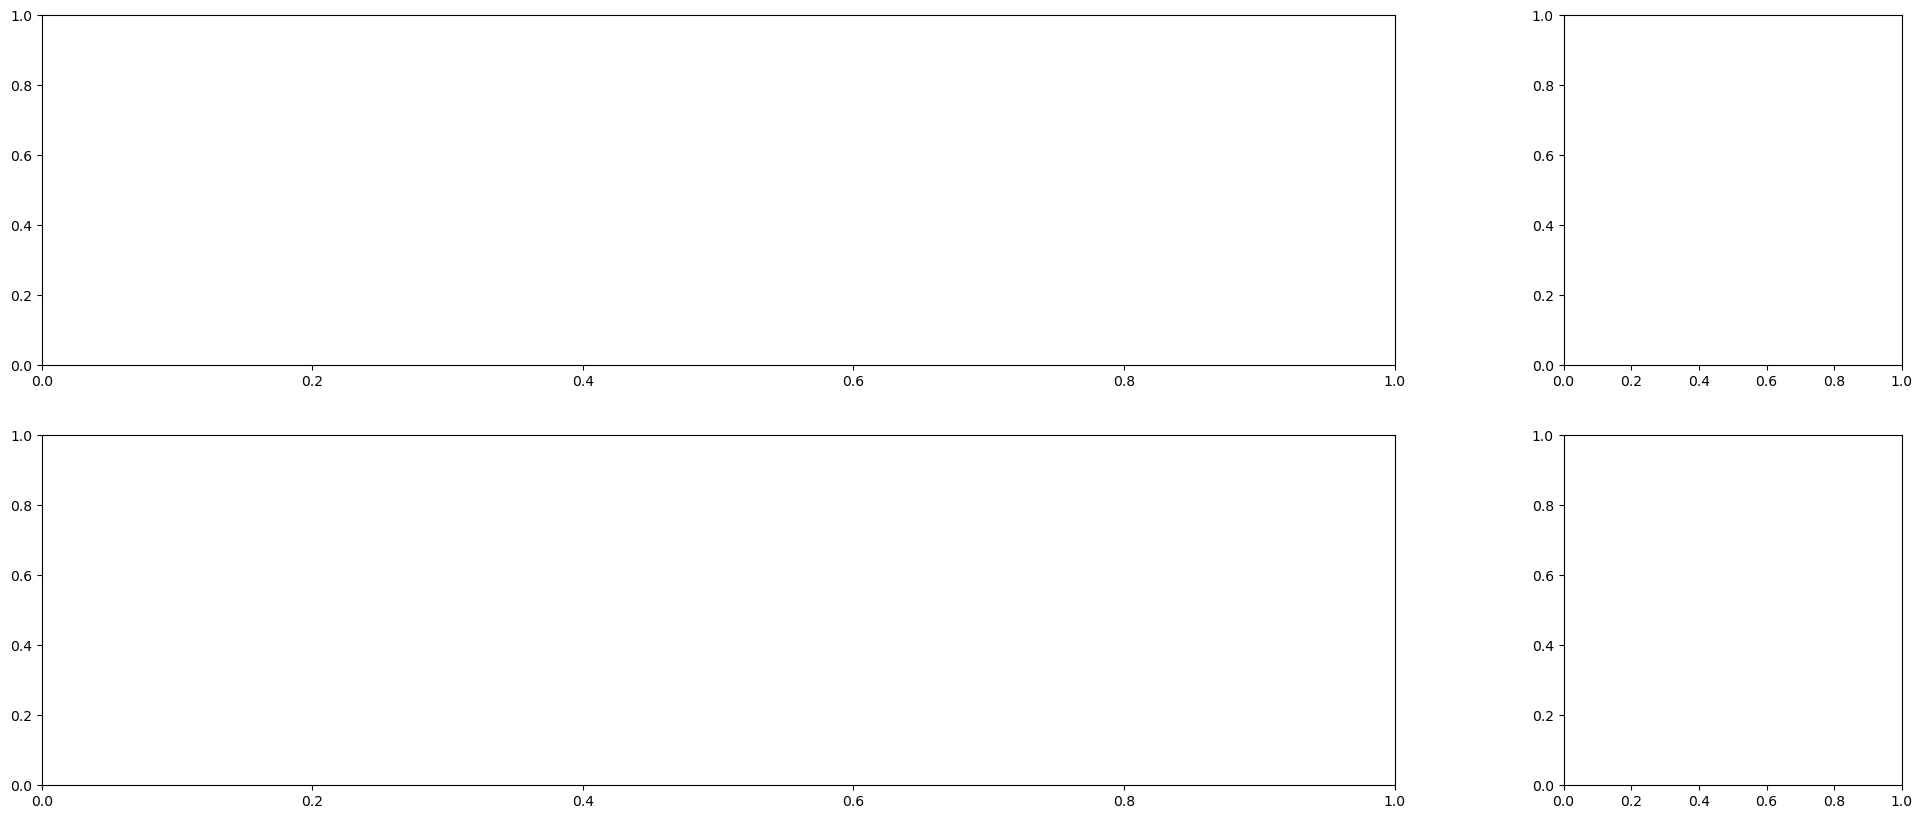

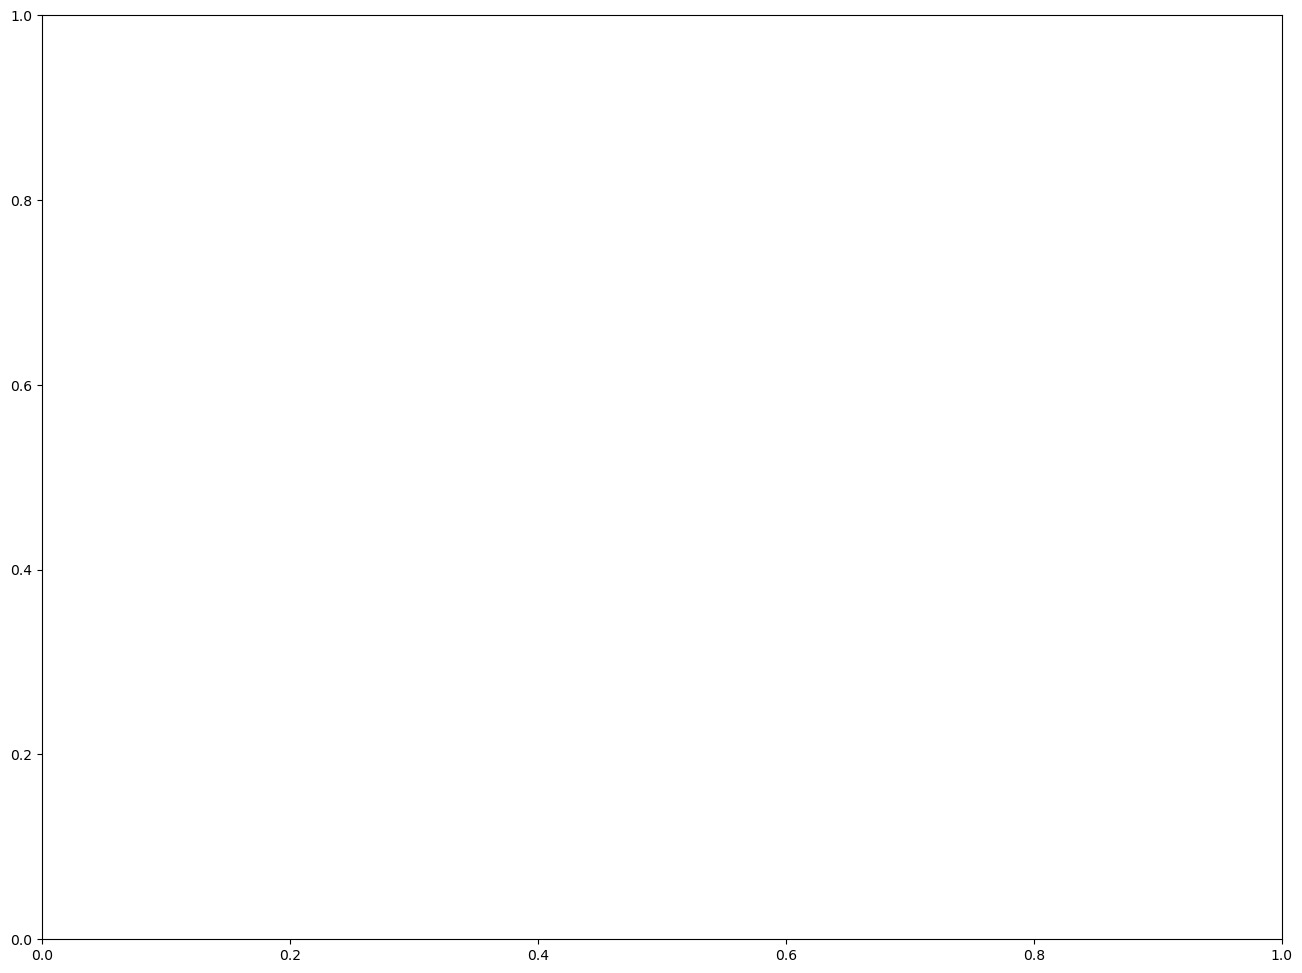

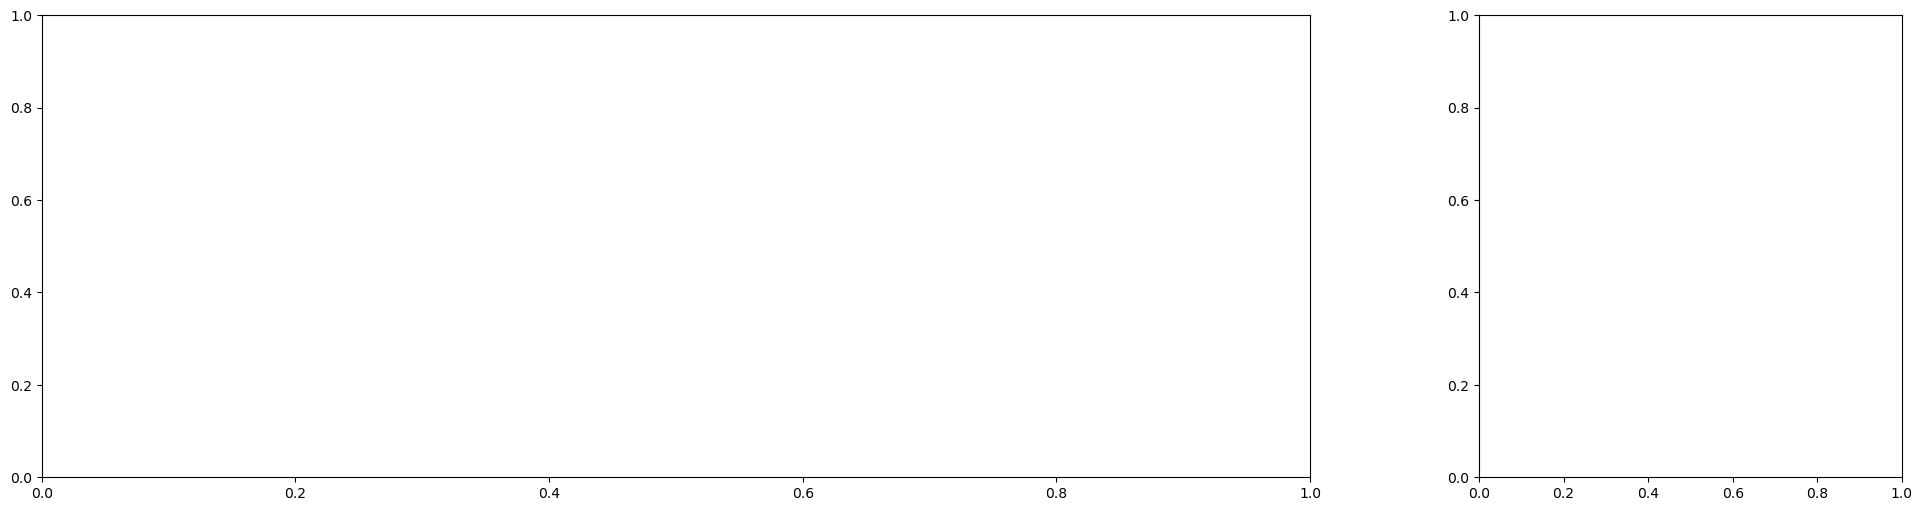

In [484]:
# Mask edge timesteps after smoothing (moving-average boundary values are unreliable)
# FIX: was smooth_tstep//2-1, which evaluates to 0 for smooth_tstep=3 (no masking)
edge_tstep = smooth_tstep // 2
nt_noedge  = np.r_[0:edge_tstep, -edge_tstep:0] if edge_tstep > 0 else np.array([], dtype=int)

dlev    = (cmax - cmin) / 10
plevels = np.arange(cmin, cmax + dlev, dlev, dtype=float)

# Figure 1: time-height contour panels, one row per case
# squeeze=False ensures ax1 is always 2-D even with a single case
fig1, ax1 = mp.subplots(ncases, 2, figsize=(24, ncases * 5),
                         gridspec_kw={'width_ratios': [4, 1]}, squeeze=False)
fig1.patch.set_facecolor('white')

# Figure 2: time-mean profiles, all cases overlaid
fig2, ax1av = mp.subplots(1, 1, figsize=(16, 12))
fig2.patch.set_facecolor('white')

# Figure 3: 1-D timeseries + summary bar chart
fig3, ax1d = mp.subplots(1, 2, figsize=(24, 6), gridspec_kw={'width_ratios': [3, 1]})
fig3.patch.set_facecolor('white')

In [485]:
pvarm_all  = None
pvar1d_all = None
pvarm0     = None
lev0       = None
vav_vline  = 0.   # default for non-ratio plot; updated inside loop

for ic in range(ncases):

    sep = '--' * 18
    print()
    print(sep)
    print(f'Case {ic+1} of {ncases}: {cnames[ic]}')
    print(sep)

    # --- Load SCAM output (try primary dir, fall back to CGD dir) ---
    # FIX: original except block rebuilt sfile_list but then still called
    #      glob.glob on the OLD sfile_list variable.
    sfile_list = pdir + cases[ic] + '/run/' + cases[ic] + '.cam.*'
    print(sfile_list)
    try:
        sfile = sorted(glob.glob(sfile_list))[0]
        print('Primary SCAM directory')
    except IndexError:
        print('CGD SCAM directory')
        sfile_list = pdir_cgd + cases[ic] + '/run/' + cases[ic] + '.cam.*'
        sfile = sorted(glob.glob(sfile_list))[0]

    print(f'File: {sfile}')
    scam_in = xr.open_dataset(sfile, engine='netcdf4').squeeze()

    # Pad to full IOP period (ARM97 timesteps can be slightly offset)
    scam_in = scam_in.reindex(time=obs_in.time, method='nearest')

    # --- Select 2D variable ---
    # FIX: original used `[vname in vderived]` (list-wrap, always True) and
    #      vderived/cp_air/Lv/grav were not in notebook scope.
    if vname in scam_in:
        pvar = scam_in[vname]
    elif vname in vderived:
        print(f'Computing derived variable: {vname}')
        if vname == 'MSE':
            pvar = cp_air * scam_in['T'] + Lv * scam_in['Q'] + grav * scam_in['Z3']
        else:
            raise NotImplementedError(f'Derived variable {vname} not implemented')
    else:
        print(f'Variable {vname} not on file -- filling with NaN')
        pvar = xr.full_like(scam_in['T'], fill_value=np.nan)

    if 'ilev' in pvar.dims:
        pvar = pvar.rename({'ilev': 'lev'})

    pvar = pvar.loc[:, plot_top:].transpose() * vscale

    # --- Time axis labels ---
    tdate     = pvar.time.dt.strftime('%H:%M %m-%d-%Y')
    tdate_day = pvar.time.dt.strftime('%m-%d-%y')
    nsteps_per_day   = 72
    nsteps_tick_span = nsteps_per_day * 3
    iticks     = np.arange(0, len(tdate) + 1, nsteps_tick_span)
    itick_days = np.arange(0, len(tdate) + 1, nsteps_per_day)

    # --- Smooth 2D field along time axis for display ---
    # pvar dims after transpose: (lev, time); apply moving average to each level's timeseries
    pvar_ma = pvar.copy()
    if smooth_tstep > 1:
        pvar_ma.values = np.apply_along_axis(
            lambda x: scam_utils.moving_average(x, smooth_tstep), axis=1, arr=pvar.values
        )
    if len(nt_noedge):
        pvar_ma.values[:, nt_noedge] = np.nan

    # --- Time-height contour plot (fig1) ---
    # FIX: original checked `var in rad_var` where `var` is undefined; should be `vname`
    pvar_plot = pvar_ma.where(pvar_ma != 0) if vname in rad_var else pvar_ma
    cf = ax1[ic, 0].contourf(tdate, pvar.lev, pvar_plot, levels=plevels, cmap=cmap)
    fig1.colorbar(cf, ax=ax1[ic, 0])
    ax1[ic, 0].contour(tdate, pvar.lev, pvar_plot, levels=plevels,
                       colors='black', linewidths=0.5)
    ax1[ic, 0].set_ylabel('Pressure (mb)', fontsize=20)
    ax1[ic, 0].set_xlabel('Time', fontsize=20)
    ax1[ic, 0].set_xticks(iticks)
    ax1[ic, 0].set_xticklabels(tdate_day[iticks].values)
    ax1[ic, 0].invert_yaxis()
    ax1[ic, 0].vlines(tdate[itick_days], min(pvar.lev), max(pvar.lev),
                      linestyle='dotted', lw=2)
    ax1[ic, 0].set_title(f'{cnames[ic]} - {vname} - {iop}', fontsize=25)
    ax1[ic, 0].tick_params(axis='both', labelsize=16)

    # --- Time-mean profile (uses unsmoothed pvar for accurate mean) ---
    pvarm = pvar.mean(axis=1)

    if ic == 0:
        pvarm0    = pvarm           # Reference profile for optional ratio plot
        lev0      = pvarm.lev
        pvarm_all = pvarm
    else:
        pvarm_int = pvarm.interp(lev=lev0, method='linear')
        pvarm_all = xr.concat([pvarm_all, pvarm_int], dim='case')

    ax1[ic, 1].plot(pvarm, pvarm.lev)
    ax1[ic, 1].set_xlim([cmin, cmax])
    ax1[ic, 1].set_title(units2d, fontsize=20)
    ax1[ic, 1].tick_params(axis='both', labelsize=18)
    ax1[ic, 1].set_ylabel('Pressure (mb)')
    ax1[ic, 1].invert_yaxis()
    ax1[ic, 1].vlines(0., min(pvar.lev), max(pvar.lev), linestyle='dotted', lw=3)
    if lobs2d:
        ax1[ic, 1].plot(var2d_o.mean(axis=0), 0.01 * var2d_o.lev, 'ko-')
        ax1[ic, 1].legend([cnames[ic], iop], fontsize=13)

    # --- 1D variable ---
    if vname1d == 'PKHMAX':
        pvar1d     = vscale1d * scam_in['KHMAX']
        pvar1d_int = pvar1d.values.astype(int)
        for itt, ill in enumerate(pvar1d_int):
            pvar1d[itt] = scam_in.lev[ill - 1]
    elif vname1d == 'PRECT':
        pvar1d = vscale1d * (scam_in['PRECC'] + scam_in['PRECL'])
    else:
        pvar1d = vscale1d * scam_in[vname1d]

    if vname1d == 'LEL':
        ipvar1d = pvar1d.astype(int) - 1
        for itt in range(len(tdate)):
            try:
                pvar1d[itt] = scam_in.lev[ipvar1d[itt]]
            except Exception:
                pass

    if ic == 0:
        pvar1d_all = pvar1d
    else:
        pvar1d_all = xr.concat([pvar1d_all, pvar1d], dim='case')

    pvar1d_ma        = pvar1d.copy()
    pvar1d_ma.values = (scam_utils.moving_average(pvar1d, smooth_tstep)
                        if smooth_tstep > 1 else pvar1d.values.copy())
    if len(nt_noedge):
        pvar1d_ma[nt_noedge] = None

    ax1d[0].plot(tdate, pvar1d_ma, line_style[ic], lw=2, markersize=5, markevery=5)

    # --- Average-profile overlay (fig2) ---
    if lvavratio_plot:
        pvarm_on_lev0 = pvarm.interp(lev=lev0, method='linear') if ic > 0 else pvarm
        vav_pvar  = pvarm_on_lev0 / pvarm0
        vav_plev  = lev0
        vav_vline = 1.
    else:
        vav_pvar  = pvarm
        vav_plev  = pvarm.lev
        vav_vline = 0.

    ax1av.plot(vav_pvar, vav_plev, line_style[ic], lw=3)

# --- Save time-height figure after loop completes ---
fig1.tight_layout()
fig1.savefig(fig_dir + cases[0] + '.' + fig_pref + '_scam_ts_' + vname + '.png',
             dpi=fdpi, facecolor='white')
print('Saved time-height figure.')


------------------------------------
Case 1 of 2: CAM6-L32
------------------------------------
/glade/work/rneale/scam_cases/cases/ZM_PBL_paper/FSCAM.T42_T42.arm95.cam7-phys.000.L32/run/FSCAM.T42_T42.arm95.cam7-phys.000.L32.cam.*
Primary SCAM directory
File: /glade/work/rneale/scam_cases/cases/ZM_PBL_paper/FSCAM.T42_T42.arm95.cam7-phys.000.L32/run/FSCAM.T42_T42.arm95.cam7-phys.000.L32.cam.h0i.1995-07-18-19800.nc

------------------------------------
Case 2 of 2: CAM6-L32inic
------------------------------------
/glade/work/rneale/scam_cases/cases/ZM_PBL_paper/FSCAM.T42_T42.arm95.cam7-phys.clm_inic.000.L32/run/FSCAM.T42_T42.arm95.cam7-phys.clm_inic.000.L32.cam.*
CGD SCAM directory


IndexError: list index out of range

In [ ]:
if lobs2d:
    ax1av.plot(var2d_o.mean(axis=0), 0.01 * var2d_o.lev, 'ko-', lw=0.5)

ax1av.set_ylabel('Pressure (mb)', fontsize=25)
ax1av.set_xlabel(units2d, fontsize=25)
ax1av.set_xlim([cmin, cmax])
ax1av.set_ylim([100, 1050])
ax1av.tick_params(axis='both', labelsize=14)
ax1av.set_title(f'{vname} - {iop}', fontsize=20)
ax1av.vlines(vav_vline, min(pvar.lev), max(pvar.lev), linestyle='dotted', lw=2)
ax1av.invert_yaxis()
ax1av.legend(list(np.append(cnames, iop)) if lobs2d else list(cnames), fontsize=22)

fig2.savefig(fig_dir + cases[0] + '.' + fig_pref + '_scam_aves_' + vname + '.png', dpi=fdpi)
print('Saved average profile figure.')

In [486]:
cnames_all    = np.append(cnames, iop) if lobs1d else np.array(cnames)
# atleast_2d handles the ncases==1 edge case where pvar1d_all is still 1-D
pvar1d_np     = np.atleast_2d(np.array(pvar1d_all))
cnames_all_ts = list(cnames)

if lobs1d:
    # Smoothed obs timeseries
    pvar1d_mo        = var1d_o.copy()
    pvar1d_mo.values = (scam_utils.moving_average(var1d_o, smooth_tstep)
                        if smooth_tstep > 1 else var1d_o.values.copy())
    if len(nt_noedge):
        pvar1d_mo[nt_noedge] = None
    ax1d[0].plot(tdate, pvar1d_mo, 'k', lw=4, linestyle='dashed')

    # Correlation labels
    # FIX: original called `.data` on the numpy.float64 return of corrcoef_ignore_nan,
    #      which gives a memoryview buffer instead of a number.
    cnames_all_ts = []
    for ii in range(ncases):
        corr_val = scam_utils.corrcoef_ignore_nan(pvar1d_np[ii, :], var1d_o.data)
        cnames_all_ts.append(f'{cnames[ii]} - [{np.round(corr_val, decimals=3)}]')
    cnames_all_ts.append(iop)

    # Stack obs row so bar chart includes observations
    pvar1d_np = np.vstack([pvar1d_np, [var1d_o.values]])

ax1d[0].legend(cnames_all_ts, fontsize=15)
ax1d[0].tick_params(axis='both', labelsize=15)
ax1d[0].set_xlabel('Time', fontsize=20)
ax1d[0].set_ylabel(units1d, fontsize=20)
ax1d[0].set_xlim([tdate[0], tdate[-1]])
ax1d[0].set_xticks(iticks)
ax1d[0].set_xticklabels(tdate_day[iticks].values)
ax1d[0].vlines(tdate[itick_days], pmin, pmax, linestyle='dotted', lw=2)
ax1d[0].set_title(f'{vname1d} - {iop}', fontsize=25)

if vname1d in ['LEL', 'PLCL', 'PKHMAX']:
    ax1d[0].invert_yaxis()

scam_figs.scam_bar(ax1d[1], pvar1d_np, cnames_all, units1d)
fig3.savefig(fig_dir + cases[0] + '.' + fig_pref + '_scam_1d_' + vname1d + '.png', dpi=fdpi)
print('Saved 1D timeseries figure.')

Correlation coefficient ignoring NaNs: [[1.         0.65221155]
 [0.65221155 1.        ]]


IndexError: index 1 is out of bounds for axis 0 with size 1